## 1학기 복습 -연습(2-3)

### 1.수업을 위한 data  활용을 위해 깃허브 연동하기

In [2]:
!git clone 'https://'github.com/KangKyungHwa/DSMH_2/''

fatal: destination path 'DSMH_2' already exists and is not an empty directory.


### 2. 원활한 한글 인식을 위해 폰트 설치

In [3]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: sk

### 3. 나눔고딕 설치

In [4]:
from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.unicode_minus'] = False

### 4.현재 설치된 폰트 확인

In [5]:
import matplotlib.pyplot as plt

print("현재 Matplotlib 폰트 설정:", plt.rcParams['font.family']) #현재 설치된 폰트 확인


현재 Matplotlib 폰트 설정: ['NanumGothic']


### 5. housing_data.csv 데이터셋 불러오기

In [6]:
import pandas as pd

df = pd.read_csv("DSMH_2/8_27/housing_data.csv", header = None, sep=',')

print( df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       506 non-null    float64
 1   1       526 non-null    float64
 2   2       526 non-null    float64
 3   3       526 non-null    int64  
 4   4       526 non-null    float64
 5   5       526 non-null    float64
 6   6       526 non-null    float64
 7   7       526 non-null    float64
 8   8       526 non-null    int64  
 9   9       526 non-null    float64
 10  10      526 non-null    float64
 11  11      526 non-null    float64
 12  12      526 non-null    float64
 13  13      526 non-null    float64
 14  14      526 non-null    int64  
dtypes: float64(12), int64(3)
memory usage: 61.8 KB
None


### 6. 내 PC에서 파일 업로드하기

아래 코드를 실행하면 파일 선택 대화상자가 나타나고, 여기서 로컬 PC에 있는 파일을 선택하여 Colab 환경으로 업로드할 수 있습니다.

In [7]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

# 여러 파일이 업로드될 경우 반복문을 통해 처리
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  df_uploaded = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
  display(df_uploaded.head())

Saving housing_data.csv to housing_data (1).csv
User uploaded file "housing_data (1).csv" with length 39461 bytes


,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.09,1,296.0,15.3,396.9,4.98,24.0,0.1
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,0
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,1
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,1
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,1
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7,1


### 6. 컬럼이름이 없으므로 컬럼명을 지정해 줌

In [8]:

col_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV','isHighValue']
df_uploaded.columns = col_names


print(df_uploaded.head(3),'\n')
print(df_uploaded.shape,'\n')  #행과 열 갯수 알아보기

print(df_uploaded.info(),'\n')

print(df_uploaded.isnull().sum(),'\n')
print(df_uploaded.isnull().sum()/df_uploaded.shape[0])   #결측값 비율 알기



      CRIM   ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  PTRATIO  \
0  0.02731  0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0     17.8   
1  0.02729  0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0     17.8   
2  0.03237  0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0     18.7   

        B  LSTAT  MEDV  isHighValue  
0  396.90   9.14  21.6            0  
1  392.83   4.03  34.7            1  
2  394.63   2.94  33.4            1   

(525, 15) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CRIM         505 non-null    float64
 1   ZN           525 non-null    float64
 2   INDUS        525 non-null    float64
 3   CHAS         525 non-null    int64  
 4   NOX          525 non-null    float64
 5   RM           525 non-null    float64
 6   AGE          525 non-null    float64
 7   DIS          525 non-

### 7.  결측치가 많지 않으므로 제거하기로 결정

In [9]:

df = df_uploaded.loc[df_uploaded['CRIM'].notnull(),]
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  505.000000  505.000000  505.000000  505.000000  505.000000  505.000000   
mean     3.620667   11.350495   11.154257    0.069307    0.554728    6.284059   
std      8.608572   23.343704    6.855868    0.254227    0.115990    0.703195   
min      0.009060    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082210    0.000000    5.190000    0.000000    0.449000    5.885000   
50%      0.259150    0.000000    9.690000    0.000000    0.538000    6.208000   
75%      3.678220   12.500000   18.100000    0.000000    0.624000    6.625000   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  505.000000  505.000000  505.000000  505.000000  505.000000  505.000000   
mean    68.581584    3.794459    9.566337  408.459406   18.461782  356.594376   
std     28.176371    2.1077

### 8. CRIM 컬럼의 왜도 그려보기

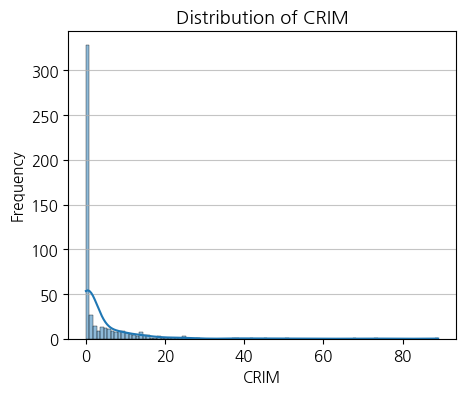

CRIM 컬럼의 왜도: 5.2184


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'CRIM' 컬럼의 분포를 히스토그램으로 시각화
plt.figure(figsize=(5, 4))
sns.histplot(df['CRIM'], kde=True)
plt.title('Distribution of CRIM')
plt.xlabel('CRIM')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 'CRIM' 컬럼의 왜도(Skewness) 계산 및 출력          # 왜도 값이 3 이상이면 크게 치우쳐져 있다고 봄
print(f"CRIM 컬럼의 왜도: {df['CRIM'].skew():.4f}")



### 9. 왜도값이 크게 나왔으므로  로그변환을 해준다.

1.2665800822867268


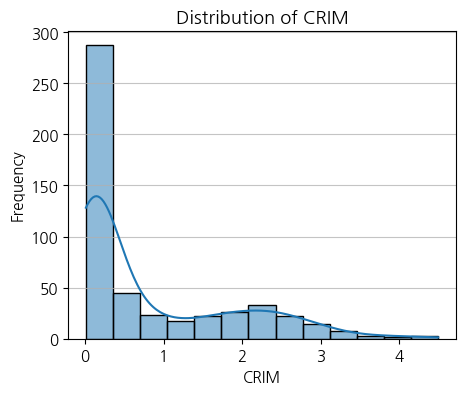

In [11]:
import numpy as np

df.loc[:, 'CRIM'] = np.log1p(df['CRIM'])
print(df['CRIM'].skew())


plt.figure(figsize=(5, 4))
sns.histplot(df['CRIM'], kde=True)
plt.title('Distribution of CRIM')
plt.xlabel('CRIM')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()